Using device: cpu
Training samples : 60000
Test samples     : 10000

Training: Basic Denoising Convolutional Autoencoder
  Epoch [ 1/20]  Train: 0.11305  Val: 0.11396
  Epoch [ 5/20]  Train: 0.11200  Val: 0.11396
  Epoch [10/20]  Train: 0.11200  Val: 0.11396
  Epoch [15/20]  Train: 0.11200  Val: 0.11396
  Epoch [20/20]  Train: 0.11200  Val: 0.11396


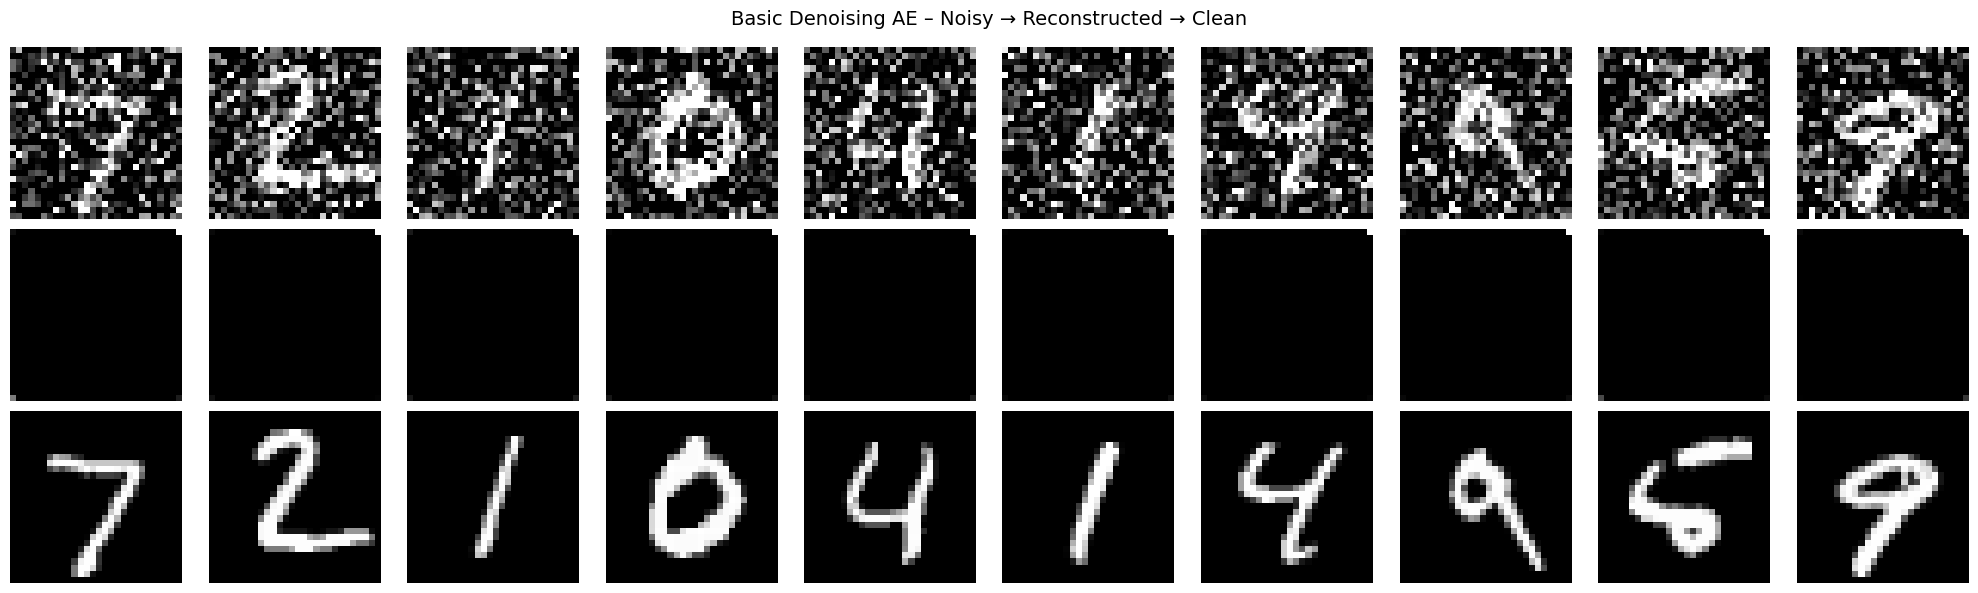

Saved: basic_denoising_ae.png

Training: Deep Denoising Autoencoder  [TASK 1]
  Epoch [ 1/20]  Train: 0.01586  Val: 0.01018
  Epoch [ 5/20]  Train: 0.00896  Val: 0.00852
  Epoch [10/20]  Train: 0.00846  Val: 0.00825
  Epoch [15/20]  Train: 0.00819  Val: 0.00801
  Epoch [20/20]  Train: 0.00800  Val: 0.00784


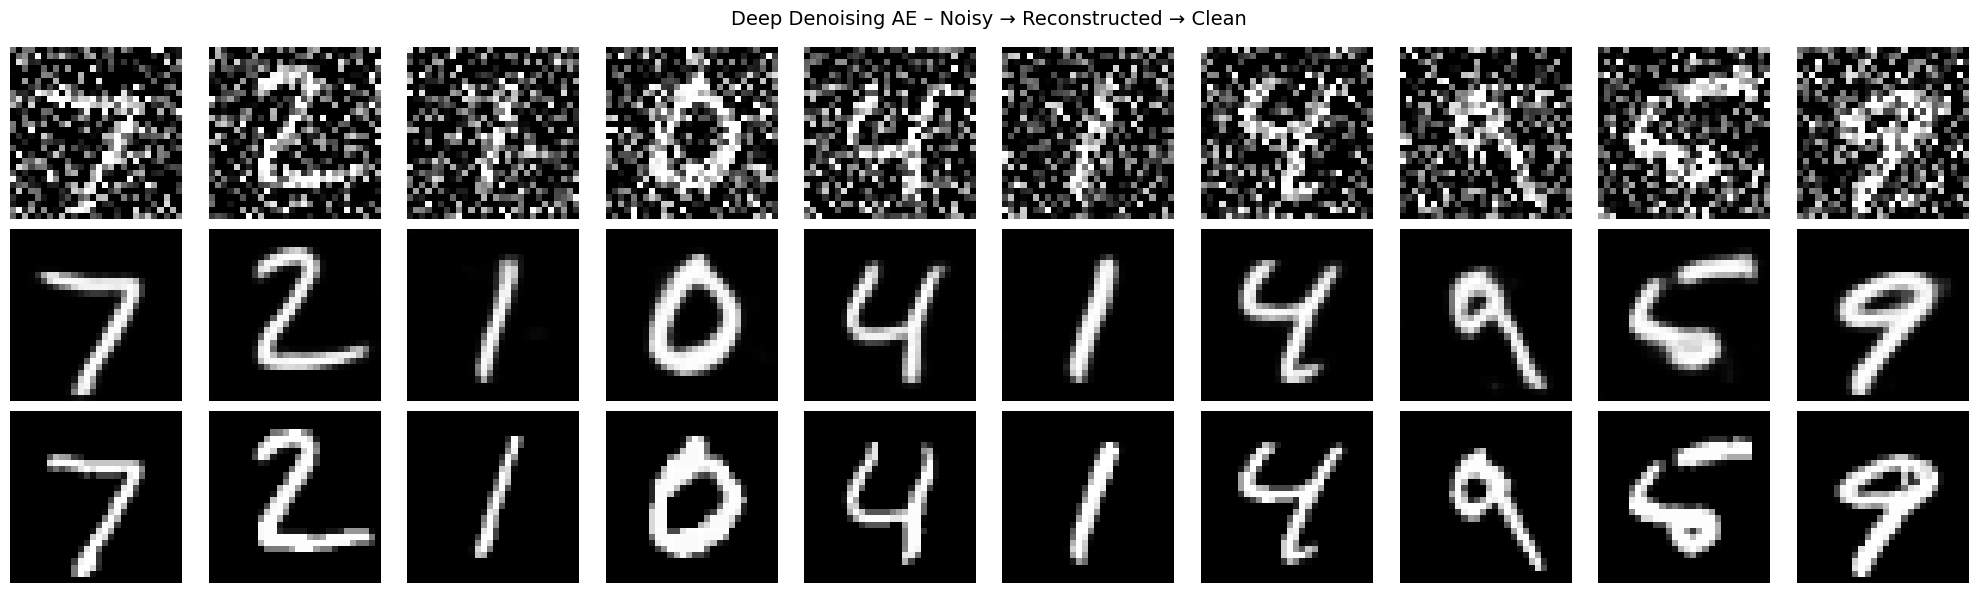

Saved: deep_denoising_ae.png

Training: Variational Autoencoder  [TASK 2]
  Epoch [ 1/20]  Train: 187.96751  Val: 127.01542
  Epoch [ 5/20]  Train: 116.16642  Val: 106.38747
  Epoch [10/20]  Train: 112.67838  Val: 103.55438
  Epoch [15/20]  Train: 111.13625  Val: 101.76406
  Epoch [20/20]  Train: 110.14594  Val: 100.72108


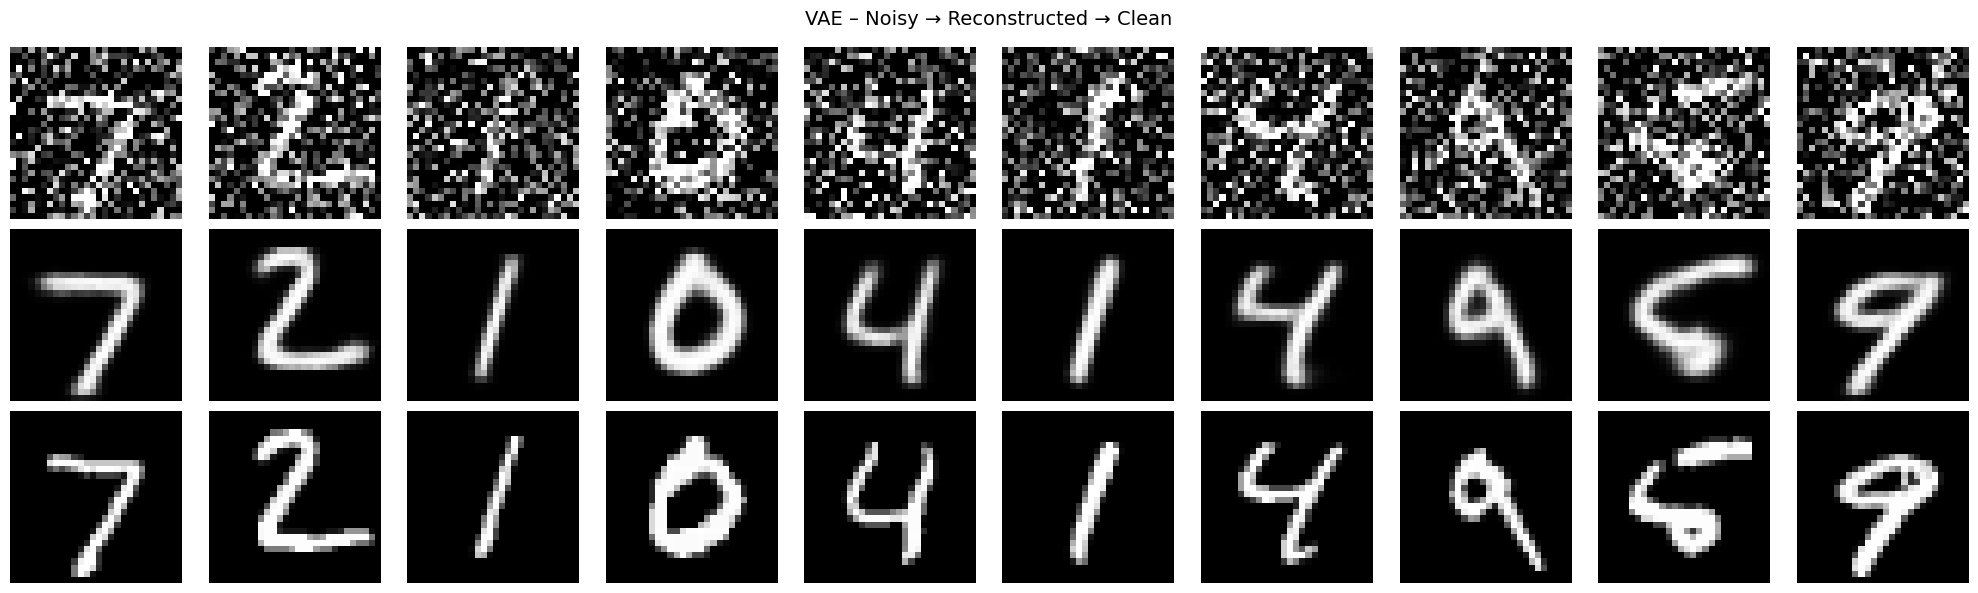

Saved: vae_denoising.png


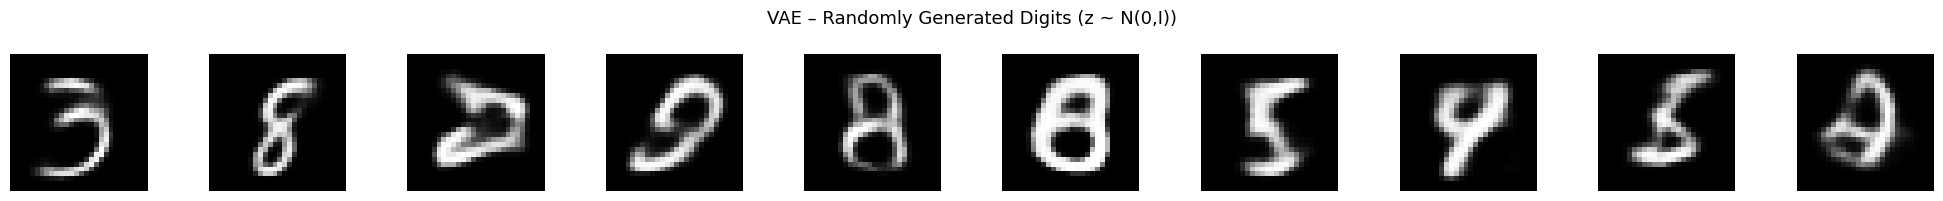

Saved: vae_generated_samples.png


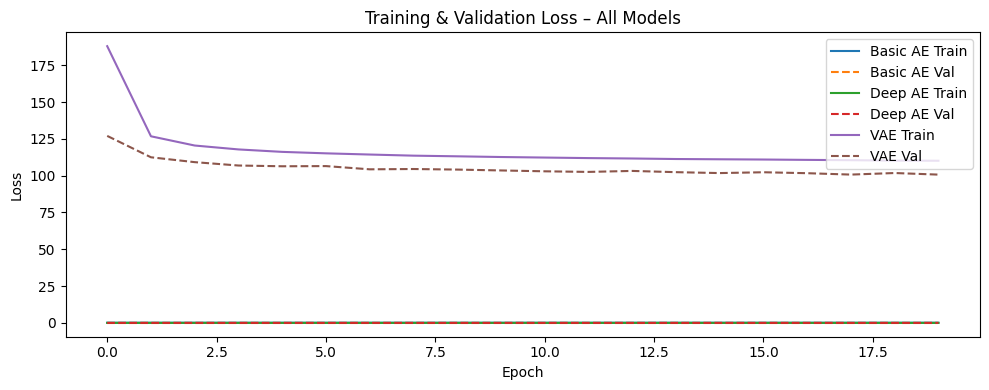

Saved: all_models_loss.png

All done! Files saved:
  basic_denoising_ae.png
  deep_denoising_ae.png
  vae_denoising.png
  vae_generated_samples.png
  all_models_loss.png


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# Device Configuration
# ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ─────────────────────────────────────────
# Load Dataset
# ─────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

# ─────────────────────────────────────────
# Add Noise to Images
# ─────────────────────────────────────────
def add_noise(images: torch.Tensor, noise_factor: float = 0.5) -> torch.Tensor:
    """Add Gaussian noise and clip to [0, 1]."""
    noise = noise_factor * torch.randn_like(images)
    return torch.clamp(images + noise, 0.0, 1.0)


# ══════════════════════════════════════════════════════════════════════
# ── MODEL 1: Basic Denoising Convolutional Autoencoder ────────────────
# ══════════════════════════════════════════════════════════════════════
class BasicDenoisingAE(nn.Module):
    """
    Convolutional autoencoder that takes a NOISY image as input
    and reconstructs the CLEAN image.
    Architecture mirrors the Keras baseline from the tutorial.
    """
    def __init__(self):
        super().__init__()
        # Encoder: 28×28 → 14×14 → 7×7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                              # 14×14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                              # 7×7
        )
        # Decoder: 7×7 → 14×14 → 28×28
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(True),
            nn.Upsample(scale_factor=2),                     # 14×14
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(True),
            nn.Upsample(scale_factor=2),                     # 28×28
            nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# ══════════════════════════════════════════════════════════════════════
# ── TASK 1: Deep Denoising Autoencoder ───────────────────────────────
# ══════════════════════════════════════════════════════════════════════
class DenoisingDeepAE(nn.Module):
    """
    Deep Denoising Autoencoder.
    Improvements over the basic version:
      • 4 encoder stages (vs 2): 32 → 64 → 128 → 256 filters
      • Stride-2 Conv replaces MaxPool for learnable downsampling
      • BatchNorm + Dropout(0.2) for regularisation
      • ConvTranspose2d for learnable upsampling
      • Residual-style skip connections between encoder blocks for
        better gradient flow and fine-detail preservation
    Input:  noisy image  (B, 1, 28, 28)
    Output: clean image  (B, 1, 28, 28)
    """

    def _enc_block(self, in_ch, out_ch, stride=2):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),
        )

    def _dec_block(self, in_ch, out_ch, stride=2, output_padding=1):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 3, stride=stride,
                               padding=1, output_padding=output_padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def __init__(self):
        super().__init__()
        # ── Encoder ──────────────────────────────
        # 28×28→14×14→7×7 (two stride-2 steps keep dims integer)
        self.enc1 = self._enc_block(1,   32,  stride=1)   # 28×28 (no spatial reduction)
        self.enc2 = self._enc_block(32,  64,  stride=2)   # 14×14
        self.enc3 = self._enc_block(64,  128, stride=2)   # 7×7
        self.enc4 = self._enc_block(128, 256, stride=1)   # 7×7  (depth only)

        # Bottleneck fully-connected projection (latent dim = 128)
        self.fc_enc  = nn.Linear(256 * 7 * 7, 128)
        self.fc_dec  = nn.Linear(128, 256 * 7 * 7)

        # ── Decoder ──────────────────────────────
        self.dec4 = self._dec_block(256, 128, stride=1, output_padding=0)  # 7×7
        self.dec3 = self._dec_block(128, 64,  stride=2, output_padding=1)  # 14×14
        self.dec2 = self._dec_block(64,  32,  stride=2, output_padding=1)  # 28×28
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # Encode
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Flatten → latent → reshape
        flat   = e4.view(e4.size(0), -1)
        latent = F.relu(self.fc_enc(flat))
        exp    = F.relu(self.fc_dec(latent))
        d      = exp.view(e4.size(0), 256, 7, 7)

        # Decode (with skip connections at matching spatial sizes)
        d = self.dec4(d)          # 7×7×128
        d = self.dec3(d + e3)     # skip from enc3: 7×7×128 → 14×14×64
        d = self.dec2(d + e2)     # skip from enc2: 14×14×64 → 28×28×32
        d = self.dec1(d + e1)     # skip from enc1: 28×28×32 → 28×28×1
        return d


# ══════════════════════════════════════════════════════════════════════
# ── TASK 2: Variational Autoencoder (with denoising) ─────────────────
# ══════════════════════════════════════════════════════════════════════
class VAE(nn.Module):
    """
    Convolutional Variational Autoencoder.
    • Encoder outputs μ and log σ² of the latent Gaussian distribution.
    • Reparameterisation trick allows gradients to flow through sampling.
    • Decoder reconstructs the clean image from a sampled latent vector z.
    • Loss = Reconstruction Loss (BCE) + KL Divergence
    • When fed noisy images during training it learns to denoise.
    Latent dimension: 32
    """
    LATENT_DIM = 32

    def __init__(self):
        super().__init__()
        # ── Encoder ──────────────────────────────
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(True),   # 14×14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),  # 7×7
            nn.Conv2d(64, 128, 3, stride=1, padding=1), nn.ReLU(True), # 7×7
        )
        self.fc_mu     = nn.Linear(128 * 7 * 7, self.LATENT_DIM)
        self.fc_logvar = nn.Linear(128 * 7 * 7, self.LATENT_DIM)

        # ── Decoder ──────────────────────────────
        self.fc_decode = nn.Linear(self.LATENT_DIM, 128 * 7 * 7)
        self.dec_conv  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=1),                        # 7×7
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),       # 14×14
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1,  3, stride=2, padding=1, output_padding=1),       # 28×28
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc_conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        """z = μ + σ·ε,  ε ~ N(0, I)"""
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu   # deterministic at inference

    def decode(self, z):
        h = F.relu(self.fc_decode(z)).view(z.size(0), 128, 7, 7)
        return self.dec_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon_x, x, mu, logvar):
    """
    ELBO loss = Reconstruction (BCE) + KL Divergence
    KL  = -0.5 * Σ(1 + log σ² - μ² - σ²)
    """
    bce = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (bce + kld) / x.size(0)


# ─────────────────────────────────────────
# Generic Training Loop
# ─────────────────────────────────────────
def train_model(model, optimizer, epochs, is_vae=False, noise_factor=0.5):
    train_losses, val_losses = [], []
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=3, factor=0.5)

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────
        model.train()
        running = 0.0
        for clean, _ in train_loader:
            clean = clean.to(device)
            noisy = add_noise(clean, noise_factor)

            optimizer.zero_grad()
            if is_vae:
                recon, mu, logvar = model(noisy)
                loss = vae_loss(recon, clean, mu, logvar)
            else:
                recon = model(noisy)
                loss  = F.mse_loss(recon, clean)
            loss.backward()
            optimizer.step()
            running += loss.item() * clean.size(0)

        train_loss = running / len(train_loader.dataset)

        # ── Validate ──────────────────────
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for clean, _ in test_loader:
                clean = clean.to(device)
                noisy = add_noise(clean, noise_factor)
                if is_vae:
                    recon, mu, logvar = model(noisy)
                    loss = vae_loss(recon, clean, mu, logvar)
                else:
                    recon = model(noisy)
                    loss  = F.mse_loss(recon, clean)
                running_val += loss.item() * clean.size(0)

        val_loss = running_val / len(test_loader.dataset)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch [{epoch:>2}/{epochs}]  "
                  f"Train: {train_loss:.5f}  Val: {val_loss:.5f}")

    return train_losses, val_losses


# ─────────────────────────────────────────
# Visualisation Helper
# ─────────────────────────────────────────
def visualize(model, title, filename, is_vae=False, n=10, noise_factor=0.5):
    model.eval()
    clean_batch, _ = next(iter(test_loader))
    clean_batch = clean_batch[:n].to(device)
    noisy_batch = add_noise(clean_batch, noise_factor)

    with torch.no_grad():
        if is_vae:
            recon_batch, _, _ = model(noisy_batch)
        else:
            recon_batch = model(noisy_batch)

    noisy_np  = noisy_batch.cpu().numpy()
    recon_np  = recon_batch.cpu().numpy()
    clean_np  = clean_batch.cpu().numpy()

    fig, axes = plt.subplots(3, n, figsize=(20, 6))
    row_labels = ["Noisy Input", "Reconstructed", "Ground Truth"]
    rows       = [noisy_np, recon_np, clean_np]

    for r, (label, data) in enumerate(zip(row_labels, rows)):
        for i in range(n):
            ax = axes[r, i]
            ax.imshow(data[i].reshape(28, 28), cmap="gray")
            ax.axis("off")
            if i == 0:
                ax.set_ylabel(label, fontsize=9)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
    print(f"Saved: {filename}")


def plot_losses(losses_dict, title, filename):
    plt.figure(figsize=(10, 4))
    for label, (train_l, val_l) in losses_dict.items():
        plt.plot(train_l, label=f"{label} Train")
        plt.plot(val_l,   label=f"{label} Val", linestyle="--")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend(); plt.tight_layout()
    plt.savefig(filename, dpi=150); plt.show()
    print(f"Saved: {filename}")


# ══════════════════════════════════════════════════════════════════════
# ── MAIN: Train & Evaluate All Three Models ───────────────────────────
# ══════════════════════════════════════════════════════════════════════
EPOCHS       = 20      # increase for better quality; 20 is a good demo
NOISE_FACTOR = 0.5

# ── 1. Basic Denoising AE ────────────────────────────────────────────
print("\n" + "="*60)
print("Training: Basic Denoising Convolutional Autoencoder")
print("="*60)
basic_ae = BasicDenoisingAE().to(device)
opt_basic = optim.Adam(basic_ae.parameters(), lr=1e-3)
loss_basic = train_model(basic_ae, opt_basic, EPOCHS, noise_factor=NOISE_FACTOR)
visualize(basic_ae, "Basic Denoising AE – Noisy → Reconstructed → Clean",
          "basic_denoising_ae.png", noise_factor=NOISE_FACTOR)

# ── 2. Deep Denoising AE (Task 1) ────────────────────────────────────
print("\n" + "="*60)
print("Training: Deep Denoising Autoencoder  [TASK 1]")
print("="*60)
deep_ae  = DenoisingDeepAE().to(device)
opt_deep = optim.Adam(deep_ae.parameters(), lr=1e-3)
loss_deep = train_model(deep_ae, opt_deep, EPOCHS, noise_factor=NOISE_FACTOR)
visualize(deep_ae, "Deep Denoising AE – Noisy → Reconstructed → Clean",
          "deep_denoising_ae.png", noise_factor=NOISE_FACTOR)

# ── 3. Variational AE (Task 2) ───────────────────────────────────────
print("\n" + "="*60)
print("Training: Variational Autoencoder  [TASK 2]")
print("="*60)
vae      = VAE().to(device)
opt_vae  = optim.Adam(vae.parameters(), lr=1e-3)
loss_vae = train_model(vae, opt_vae, EPOCHS, is_vae=True, noise_factor=NOISE_FACTOR)
visualize(vae, "VAE – Noisy → Reconstructed → Clean",
          "vae_denoising.png", is_vae=True, noise_factor=NOISE_FACTOR)

# ── VAE: Generate new digits from random latent vectors ──────────────
vae.eval()
with torch.no_grad():
    z_sample = torch.randn(10, VAE.LATENT_DIM).to(device)
    generated = vae.decode(z_sample).cpu().numpy()

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.suptitle("VAE – Randomly Generated Digits (z ~ N(0,I))", fontsize=13)
plt.tight_layout()
plt.savefig("vae_generated_samples.png", dpi=150)
plt.show()
print("Saved: vae_generated_samples.png")

# ── Combined loss plot ────────────────────────────────────────────────
plot_losses(
    {"Basic AE": loss_basic, "Deep AE": loss_deep, "VAE": loss_vae},
    "Training & Validation Loss – All Models",
    "all_models_loss.png",
)

print("\nAll done! Files saved:")
print("  basic_denoising_ae.png")
print("  deep_denoising_ae.png")
print("  vae_denoising.png")
print("  vae_generated_samples.png")
print("  all_models_loss.png")